# Five-dataset ESM-C LLR-prior popDMS analysis

This is the multi-dataset counterpart of `clinprotgym_brca1_sae_downstream_analysis.ipynb`.
It uses the current count/frequency and ClinVar fields in `new_clean_data`, joined by protein
sequence to the already-calculated ESM-C caches. The primary downstream analysis is the
popDMS LLR prior for the singular ESM-C 300M and 600M models, including both gamma and alpha
grid searches. Mean/min/max model combinations are deliberately excluded.

BRCA1 may use its existing SAE benchmark results. SAE results from MSH2, BRCA2, VHL, and TP53
are never read by the primary analysis; optional job cells are provided to calculate them
separately. All submission switches default to `False`.

In [1]:
from pathlib import Path

In [2]:
import os, pickle, subprocess, sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "esmDMS.py").is_file():
    REPO_ROOT = next(parent for parent in Path.cwd().parents if (parent / "esmDMS.py").is_file())
sys.path.insert(0, str(REPO_ROOT))
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.sparse.linalg import LinearOperator, cg
from scipy.stats import pearsonr, spearmanr
from paperPop import get_best_regularization as paper_popdms_gamma
from scripts import clinprotgym_esmc_sae_pipeline as pipeline
sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.titlesize": 15,
    "figure.titleweight": "semibold",
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
})

AUC_LABEL = "Assay-oriented ClinVar AUC"
BEST_MARKER = {"marker": "*", "s": 200, "color": "#FFD447",
               "edgecolor": "black", "linewidth": 0.8, "zorder": 5}
BASELINE_ORDER = ["DMS functional score", "Enrichment ratio", "Regular popDMS",
                  "Raw embeddings", "Raw SAE", "Raw ESM-C 300M LLR", "Raw ESM-C 600M LLR"]
METHOD_ORDER = ["ESM-C 300M: best alpha + gamma", "Pure ESM-C 300M LLR",
                "ESM-C 600M: best alpha + gamma", "Pure ESM-C 600M LLR"]
# One colour per named series, reused by every figure so a method reads the same everywhere.
_SERIES = ["ESM-C 300M: best alpha + gamma", "ESM-C 600M: best alpha + gamma",
           "Pure ESM-C 300M LLR", "Pure ESM-C 600M LLR", "DMS functional score",
           "Enrichment ratio", "Regular popDMS", "Raw embeddings", "Raw SAE"]
SERIES_COLORS = dict(zip(_SERIES, sns.color_palette("colorblind", len(_SERIES))))
SERIES_COLORS["Raw ESM-C 300M LLR"] = SERIES_COLORS["Pure ESM-C 300M LLR"]
SERIES_COLORS["Raw ESM-C 600M LLR"] = SERIES_COLORS["Pure ESM-C 600M LLR"]

def finalize_figure(fig, filename, suptitle=None, rect=None):
    """Apply the shared title/layout/save/show sequence used by every figure."""
    if suptitle:
        fig.suptitle(suptitle)
    fig.tight_layout(rect=rect) if rect is not None else fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename)
    plt.show()

def tidy_heatmap(ax):
    """Heatmaps draw their own cells, so the darkgrid gridlines only add noise."""
    ax.grid(False)
    ax.tick_params(length=0)

DATASETS = [
    "MV_BRCA1_Findlay_2018", "MV_MSH2_Jia_2020", "MV_BRCA2_Huang_2025",
    "MV_VHL_Buckley_2024", "MV_TP53_Kotler_2018",
]
SHORT_NAMES = {
    "MV_BRCA1_Findlay_2018": "BRCA1", "MV_MSH2_Jia_2020": "MSH2",
    "MV_BRCA2_Huang_2025": "BRCA2", "MV_VHL_Buckley_2024": "VHL",
    "MV_TP53_Kotler_2018": "TP53",
}
POLARITY_VERSION = "assay-oriented-v1"
PATHOGENIC_HIGH_SELECTION = {
    "MV_BRCA1_Findlay_2018": False,
    "MV_MSH2_Jia_2020": True,
    "MV_BRCA2_Huang_2025": False,
    "MV_VHL_Buckley_2024": False,
    "MV_TP53_Kotler_2018": True,
}
LLR_TO_SELECTION_SIGN = {
    dataset: (-1.0 if pathogenic_high else 1.0)
    for dataset, pathogenic_high in PATHOGENIC_HIGH_SELECTION.items()
}
MODELS = {"ESM-C 300M": "biohub__ESMC-300M", "ESM-C 600M": "biohub__ESMC-600M"}
OUTPUT_ROOT = REPO_ROOT / "data" / "clinprotgym_esmc_sae"
JOINED_DIR = REPO_ROOT / "new_clean_data" / "joined_embeddings"
ANALYSIS_ROOT = OUTPUT_ROOT / "multi_dataset_llr_prior"
TABLE_DIR = ANALYSIS_ROOT / "tables"
FIGURE_DIR = ANALYSIS_ROOT / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PIPELINE = REPO_ROOT / "scripts" / "clinprotgym_esmc_sae_pipeline.py"
PYTHON = str(Path(sys.executable).resolve())

REVIEW_STAR_CUTOFFS = [0, 1, 2, 3]
GAMMA_GRID = np.logspace(-5, 4, num=52)
ALPHA_GENERAL_POINTS = 13
PLOT_STAR_CUTOFF = 0
RUN_BASELINE_RECOMPUTE = False
RUN_ALPHA_GAMMA_SWEEPS = False  # True=recompute/overwrite; False=load current caches only.

# Job switches: change only the action you intend to launch.
SUBMIT_LLR_JOBS = False
SUBMIT_OPTIONAL_NON_BRCA1_SAE_JOBS = False
COLLECT_OPTIONAL_NON_BRCA1_SAE = False
SUBMIT_OPTIONAL_NON_BRCA1_SAE_BENCHMARKS = False

def sh(command, run=False):
    command = [str(part) for part in command]
    print(" ".join(command))
    return subprocess.run(command, check=True) if run else None

print("Joined data:", JOINED_DIR)
print("Analysis outputs:", ANALYSIS_ROOT)

Joined data: /net/dali/home/barton/dhw28/popDMS/esmDMS/new_clean_data/joined_embeddings
Analysis outputs: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/multi_dataset_llr_prior


## Joined data and cache coverage

The analysis join is `mutated_sequence -> SequenceIndex`. Stop variants are kept in separate
exclusion tables because the existing ESM-C pipeline does not embed `*`. This audit fails if
any non-stop sequence is missing or if either singular model lacks max-pool layer files.

In [3]:
join_manifest = pd.read_csv(JOINED_DIR / "join_manifest.csv")
embedding_manifest = pd.read_csv(JOINED_DIR / "embedding_file_manifest.csv")
assert set(join_manifest["dataset"]) == set(DATASETS)
assert join_manifest["missing_non_stop_rows"].eq(0).all()
coverage = embedding_manifest.groupby(["dataset", "model"])["layer"].nunique().unstack(fill_value=0)
assert (coverage > 0).all().all()
display(join_manifest)
display(coverage)

,dataset,source_rows,joined_non_stop_rows,excluded_stop_rows,missing_non_stop_rows,sae_used_downstream,source_csv,joined_csv
0,MV_BRCA1_Findlay_2018,1956,1837,119,0,True,new_clean_data/MV_BRCA1_Findlay_2018.csv,new_clean_data/joined_embeddings/MV_BRCA1_Find...
1,MV_MSH2_Jia_2020,17746,17746,0,0,False,new_clean_data/MV_MSH2_Jia_2020.csv,new_clean_data/joined_embeddings/MV_MSH2_Jia_2...
2,MV_BRCA2_Huang_2025,4333,4064,269,0,False,new_clean_data/MV_BRCA2_Huang_2025.csv,new_clean_data/joined_embeddings/MV_BRCA2_Huan...
3,MV_VHL_Buckley_2024,1087,1035,52,0,False,new_clean_data/MV_VHL_Buckley_2024.csv,new_clean_data/joined_embeddings/MV_VHL_Buckle...
4,MV_TP53_Kotler_2018,3158,2967,191,0,False,new_clean_data/MV_TP53_Kotler_2018.csv,new_clean_data/joined_embeddings/MV_TP53_Kotle...


model,ESMC-300M,ESMC-600M
dataset,,
MV_BRCA1_Findlay_2018,31,37
MV_BRCA2_Huang_2025,31,37
MV_MSH2_Jia_2020,31,37
MV_TP53_Kotler_2018,31,37
MV_VHL_Buckley_2024,31,37


## Required LLR jobs and optional SAE jobs

The LLR array contains exactly ten tasks (five datasets by two models) and is required before
the prior sweeps. The non-BRCA1 SAE path is deliberately separate. Run it in stages: submit
SAE jobs, collect them after completion, then optionally submit benchmark jobs. Nothing below
loads non-BRCA1 SAE fitness data.

In [4]:
dataset_args = list(DATASETS)
model_args = ["biohub/ESMC-300M", "biohub/ESMC-600M"]
llr_cmd = [
    PYTHON, PIPELINE, "create-llr-jobs", "--output-root", OUTPUT_ROOT,
    "--datasets", *dataset_args, "--models", *model_args,
    "--llr-mem", "48G", "--llr-time", "12:00:00", "--max-active-llr-tasks", "4",
]
if SUBMIT_LLR_JOBS:
    llr_cmd.append("--submit")
sh(llr_cmd, run=SUBMIT_LLR_JOBS)

llr_inventory = pd.DataFrame([
    {
        "dataset": dataset, "prior_model": model_label,
        "llr_path": str(dataset_root / "tables" / f"{dataset}_{model_slug}_llr_fitness.csv"),
        "complete": (dataset_root / "tables" / f"{dataset}_{model_slug}_llr_fitness.csv").is_file(),
    }
    for dataset in DATASETS
    for model_label, model_slug in MODELS.items()
    for dataset_root in [OUTPUT_ROOT / "datasets" / dataset]
])
assert len(llr_inventory) == 10
display(llr_inventory)

NON_BRCA1 = [dataset for dataset in DATASETS if dataset != "MV_BRCA1_Findlay_2018"]
sae_cmd = [
    PYTHON, PIPELINE, "create-sae-jobs", "--output-root", OUTPUT_ROOT,
    "--datasets", *NON_BRCA1, "--models", *model_args,
    "--sae-mem", "48G", "--sae-time", "08:00:00", "--max-active-sae-tasks", "10",
]
if SUBMIT_OPTIONAL_NON_BRCA1_SAE_JOBS:
    sae_cmd.append("--submit")
    sh(sae_cmd, run=True)
else:
    sh(sae_cmd, run=False)

# Collect all five so the pipeline's global SAE metrics table retains the existing BRCA1 rows.
collect_sae_cmd = [PYTHON, PIPELINE, "collect-sae", "--output-root", OUTPUT_ROOT, "--datasets", *DATASETS]
sh(collect_sae_cmd, run=COLLECT_OPTIONAL_NON_BRCA1_SAE)

sae_benchmark_cmd = [
    PYTHON, PIPELINE, "create-benchmark-jobs", "--output-root", OUTPUT_ROOT,
    "--datasets", *NON_BRCA1, "--models", *model_args, "--count-datasets-only",
    "--benchmark-mem", "48G", "--benchmark-time", "08:00:00",
    "--max-active-benchmark-tasks", "12",
]
if SUBMIT_OPTIONAL_NON_BRCA1_SAE_BENCHMARKS:
    sae_benchmark_cmd.append("--submit")
    sh(sae_benchmark_cmd, run=True)
else:
    sh(sae_benchmark_cmd, run=False)

/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12 /net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/clinprotgym_esmc_sae_pipeline.py create-llr-jobs --output-root /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae --datasets MV_BRCA1_Findlay_2018 MV_MSH2_Jia_2020 MV_BRCA2_Huang_2025 MV_VHL_Buckley_2024 MV_TP53_Kotler_2018 --models biohub/ESMC-300M biohub/ESMC-600M --llr-mem 48G --llr-time 12:00:00 --max-active-llr-tasks 4


,dataset,prior_model,llr_path,complete
0,MV_BRCA1_Findlay_2018,ESM-C 300M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
1,MV_BRCA1_Findlay_2018,ESM-C 600M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
2,MV_MSH2_Jia_2020,ESM-C 300M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
3,MV_MSH2_Jia_2020,ESM-C 600M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
4,MV_BRCA2_Huang_2025,ESM-C 300M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
5,MV_BRCA2_Huang_2025,ESM-C 600M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
6,MV_VHL_Buckley_2024,ESM-C 300M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
7,MV_VHL_Buckley_2024,ESM-C 600M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
8,MV_TP53_Kotler_2018,ESM-C 300M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
9,MV_TP53_Kotler_2018,ESM-C 600M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True


/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12 /net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/clinprotgym_esmc_sae_pipeline.py create-sae-jobs --output-root /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae --datasets MV_MSH2_Jia_2020 MV_BRCA2_Huang_2025 MV_VHL_Buckley_2024 MV_TP53_Kotler_2018 --models biohub/ESMC-300M biohub/ESMC-600M --sae-mem 48G --sae-time 08:00:00 --max-active-sae-tasks 10
/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12 /net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/clinprotgym_esmc_sae_pipeline.py collect-sae --output-root /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae --datasets MV_BRCA1_Findlay_2018 MV_MSH2_Jia_2020 MV_BRCA2_Huang_2025 MV_VHL_Buckley_2024 MV_TP53_Kotler_2018
/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12 /net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/clinprotgym_esmc_sae_pipeline.py create-benchmark-jobs --output-root /net/dali/home/barton/dhw28/popDMS/esmD

## Data, label, and metric helpers

In [5]:
PATHOGENICITY_LABELS = {"benign", "pathogenic"}

def dataset_root(dataset):
    return OUTPUT_ROOT / "datasets" / dataset

def load_joined(dataset):
    frame = pd.read_csv(JOINED_DIR / f"{dataset}_joined.csv")
    frame["SequenceIndex"] = frame["SequenceIndex"].astype(str)
    return frame

def build_vhl_trajectory():
    # VHL's post/post2 columns are replicate endpoints sharing the corresponding pre sample.
    joined = load_joined("MV_VHL_Buckley_2024")
    replicate_specs = [
        (1, "tHDR post", "count__tHDR_pre", "count__tHDR_post"),
        (2, "tHDR post2", "count__tHDR_pre", "count__tHDR_post2"),
        (3, "rLD2_tHDR post", "count__rLD2_tHDR_pre", "count__rLD2_tHDR_post"),
        (4, "rLD2_tHDR post2", "count__rLD2_tHDR_pre", "count__rLD2_tHDR_post2"),
    ]
    frames = []
    for replicate, replicate_name, initial_column, final_column in replicate_specs:
        for generation, count_column in [(0.0, initial_column), (1.0, final_column)]:
            part = joined[["SequenceIndex", "mutant"]].copy()
            part["Replicate"] = replicate
            part["ReplicateName"] = replicate_name
            part["Generation"] = generation
            part["Frequency"] = pd.to_numeric(joined[count_column], errors="coerce").fillna(0.0).clip(lower=0.0)
            part["CountColumn"] = count_column
            frames.append(part)
    return pd.concat(frames, ignore_index=True)

def load_state(dataset):
    path = dataset_root(dataset) / "sequence_data" / f"{dataset}_processed_state.pkl"
    with path.open("rb") as handle:
        state = pickle.load(handle)
    if dataset == "MV_VHL_Buckley_2024" and state["sequence_dataframe"].empty:
        state = state.copy()
        state["sequence_dataframe"] = build_vhl_trajectory()
        state["has_real_trajectory"] = True
    return state

def load_labels(dataset):
    joined = load_joined(dataset)
    labels = joined[["SequenceIndex", "clinvar_significance_normalized", "clinvar_review_status"]].copy()
    labels["annotation"] = labels["clinvar_significance_normalized"].astype(str).str.lower()
    labels["stars"] = labels["clinvar_review_status"].map(pipeline.clinvar_review_status_to_stars).astype(int)
    return labels[["SequenceIndex", "annotation", "stars"]].drop_duplicates("SequenceIndex")

def auc_from_fitness(dataset, fitness, min_stars=0, fitness_kind="selection"):
    frame = fitness[["SequenceIndex", "fitness"]].copy()
    frame["SequenceIndex"] = frame["SequenceIndex"].astype(str)
    frame["fitness"] = pd.to_numeric(frame["fitness"], errors="coerce")
    frame = frame.merge(load_labels(dataset), on="SequenceIndex", how="left")
    frame = frame[frame["stars"].ge(min_stars) & frame["annotation"].isin(PATHOGENICITY_LABELS)]
    frame = frame[np.isfinite(frame["fitness"])].copy()
    y = frame["annotation"].eq("pathogenic").to_numpy()
    if fitness_kind == "llr":
        pathogenic_high = False  # Raw ESM-C LLR: lower means more damaging.
    elif fitness_kind == "selection":
        pathogenic_high = PATHOGENIC_HIGH_SELECTION[dataset]
    else:
        raise ValueError(f"Unknown fitness_kind: {fitness_kind!r}")
    orientation_sign = 1.0 if pathogenic_high else -1.0
    scores = orientation_sign * frame["fitness"].to_numpy(dtype=float)
    n_pos, n_neg = int(y.sum()), int((~y).sum())
    if n_pos == 0 or n_neg == 0:
        auc = np.nan
    else:
        ranks = pd.Series(scores).rank(method="average").to_numpy()
        auc = float((ranks[y].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))
    return {
        "auc": auc, "auc_discrimination": auc,
        "n_benign": n_neg, "n_pathogenic": n_pos,
        "fitness_kind": fitness_kind, "pathogenic_high": pathogenic_high,
        "polarity_version": POLARITY_VERSION,
    }

def joined_score_table(dataset):
    joined = load_joined(dataset)
    out = joined[["SequenceIndex", "functional_score"]].rename(columns={"functional_score": "score"})
    out["score"] = pd.to_numeric(out["score"], errors="coerce")
    return out

def spearman_against_score(dataset, fitness):
    merged = fitness.merge(joined_score_table(dataset), on="SequenceIndex", how="inner")
    x = pd.to_numeric(merged["fitness"], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(merged["score"], errors="coerce").to_numpy(dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    return float(spearmanr(x[finite], y[finite]).statistic) if finite.sum() >= 3 else np.nan

label_audit = pd.concat([
    load_labels(dataset).assign(dataset=dataset).groupby(["dataset", "stars", "annotation"]).size().rename("n").reset_index()
    for dataset in DATASETS
], ignore_index=True)
display(label_audit[label_audit["annotation"].isin(PATHOGENICITY_LABELS)])

,dataset,stars,annotation,n
0,MV_BRCA1_Findlay_2018,0,benign,1
2,MV_BRCA1_Findlay_2018,0,pathogenic,4
4,MV_BRCA1_Findlay_2018,1,benign,87
6,MV_BRCA1_Findlay_2018,1,pathogenic,51
8,MV_BRCA1_Findlay_2018,2,benign,4
9,MV_BRCA1_Findlay_2018,2,pathogenic,78
11,MV_BRCA1_Findlay_2018,3,benign,15
13,MV_BRCA1_Findlay_2018,3,pathogenic,63
17,MV_MSH2_Jia_2020,1,benign,233
19,MV_MSH2_Jia_2020,1,pathogenic,32


## Respective baselines

Baselines are recomputed against the joined ClinVar labels. Functional score is omitted for
BRCA2 because it is unavailable. Enrichment ratio and regular zero-mean popDMS are calculated
from each dataset's trajectory (the count/frequency values match the joined non-stop rows). The
VHL adapter treats `post` and `post2` as replicate endpoints sharing each arm's `pre` sample;
library, RNA, and negative-control columns are not used. Pathogenic variants are on the
high-selection end for MSH2/TP53 and the low-selection end for BRCA1/BRCA2/VHL; AUC is computed
after this fixed orientation, and `max(AUC, 1-AUC)` is not used. Existing raw-embedding benchmarks are
included when present. Existing SAE
benchmarks are considered only for BRCA1.

In [6]:
def existing_embedding_benchmarks(dataset):
    rows = []
    result_dir = dataset_root(dataset) / "jobs" / "benchmark_row_analysis" / "results"
    for result_path in sorted(result_dir.glob("*.csv")):
        result = pd.read_csv(result_path)
        if result.empty or "method_family" not in result:
            continue
        row = result.iloc[0]
        family = str(row.get("method_family", ""))
        if family == "Raw SAE" and dataset != "MV_BRCA1_Findlay_2018":
            continue
        if family not in {"Raw embeddings", "Raw SAE"}:
            continue
        fitness_path = Path(str(row.get("fitness_path", "")))
        if not fitness_path.is_file():
            continue
        fitness = pd.read_csv(fitness_path, usecols=["SequenceIndex", "fitness"])
        for cutoff in REVIEW_STAR_CUTOFFS:
            stats = auc_from_fitness(dataset, fitness, cutoff, fitness_kind="selection")
            rows.append({
                "dataset": dataset, "baseline": family, "detail": row.get("model_label", ""),
                "min_review_stars": cutoff, **stats,
            })
    return pd.DataFrame(rows)

baseline_rows, selection_scales = [], {}
for dataset in DATASETS:
    state = load_state(dataset)
    joined = load_joined(dataset)
    score_fitness = joined[["SequenceIndex", "functional_score"]].rename(columns={"functional_score": "fitness"})
    score_fitness["fitness"] = pd.to_numeric(score_fitness["fitness"], errors="coerce")
    enrichment = pipeline.enrichment_ratio_fitness(state["sequence_dataframe"])
    selection_path = TABLE_DIR / f"{dataset}_regular_popdms_selection.csv"
    popdms_path = TABLE_DIR / f"{dataset}_regular_popdms_fitness.csv"
    if RUN_BASELINE_RECOMPUTE or not (selection_path.is_file() and popdms_path.is_file()):
        regular_popdms, selection = pipeline.popdms_substitution_fitness(
            state["sequence_dataframe"], state["sequence_metadata"]
        )
        regular_popdms.to_csv(popdms_path, index=False)
        selection.to_csv(selection_path, index=False)
    else:
        regular_popdms, selection = pd.read_csv(popdms_path), pd.read_csv(selection_path)
    selection_values = pd.to_numeric(selection["selection_coefficient"], errors="coerce").dropna()
    selection_scales[dataset] = float(selection_values.std(ddof=1))

    baseline_fitness = {
        "DMS functional score": (score_fitness, "selection"),
        "Enrichment ratio": (enrichment, "selection"),
        "Regular popDMS": (regular_popdms, "selection"),
    }
    for model_label, model_slug in MODELS.items():
        path = dataset_root(dataset) / "tables" / f"{dataset}_{model_slug}_llr_fitness.csv"
        if path.is_file():
            baseline_fitness[f"Raw {model_label} LLR"] = (
                pd.read_csv(path, usecols=["SequenceIndex", "fitness"]), "llr"
            )
    for name, (fitness, fitness_kind) in baseline_fitness.items():
        if pd.to_numeric(fitness["fitness"], errors="coerce").notna().sum() < 2:
            continue
        for cutoff in REVIEW_STAR_CUTOFFS:
            baseline_rows.append({
                "dataset": dataset, "baseline": name, "detail": name,
                "min_review_stars": cutoff,
                **auc_from_fitness(dataset, fitness, cutoff, fitness_kind=fitness_kind),
            })
    existing = existing_embedding_benchmarks(dataset)
    if not existing.empty:
        baseline_rows.extend(existing.to_dict("records"))

baselines = pd.DataFrame(baseline_rows)
# Reduce layer families to their best current-label AUC per dataset/cutoff.
baselines = (baselines.sort_values("auc_discrimination", ascending=False)
             .drop_duplicates(["dataset", "baseline", "min_review_stars"]))
baselines.to_csv(TABLE_DIR / "five_dataset_baselines.csv", index=False)
display(baselines[baselines["min_review_stars"].eq(PLOT_STAR_CUTOFF)])

,dataset,baseline,detail,min_review_stars,auc,auc_discrimination,n_benign,n_pathogenic,fitness_kind,pathogenic_high,polarity_version
0,MV_BRCA1_Findlay_2018,DMS functional score,DMS functional score,0,0.989319,0.989319,107,196,selection,False,assay-oriented-v1
2520,MV_TP53_Kotler_2018,Raw embeddings,ESMC-600M Layer_35 raw max_pool,0,0.977671,0.977671,42,209,selection,True,assay-oriented-v1
1980,MV_TP53_Kotler_2018,DMS functional score,DMS functional score,0,0.975963,0.975963,42,209,selection,True,assay-oriented-v1
1988,MV_TP53_Kotler_2018,Regular popDMS,Regular popDMS,0,0.952495,0.952495,42,209,selection,True,assay-oriented-v1
16,MV_BRCA1_Findlay_2018,Raw ESM-C 600M LLR,Raw ESM-C 600M LLR,0,0.949647,0.949647,107,196,llr,False,assay-oriented-v1
1408,MV_BRCA2_Huang_2025,Raw ESM-C 300M LLR,Raw ESM-C 300M LLR,0,0.943847,0.943847,210,77,llr,False,assay-oriented-v1
836,MV_MSH2_Jia_2020,DMS functional score,DMS functional score,0,0.942857,0.942857,280,139,selection,True,assay-oriented-v1
1992,MV_TP53_Kotler_2018,Raw ESM-C 300M LLR,Raw ESM-C 300M LLR,0,0.941786,0.941786,42,209,llr,False,assay-oriented-v1
1960,MV_VHL_Buckley_2024,DMS functional score,DMS functional score,0,0.941733,0.941733,21,161,selection,False,assay-oriented-v1
1996,MV_TP53_Kotler_2018,Raw ESM-C 600M LLR,Raw ESM-C 600M LLR,0,0.941445,0.941445,42,209,llr,False,assay-oriented-v1


## LLR-prior popDMS solver

In [7]:
def feature_index(metadata):
    seq_to_feature, rows = {}, []
    for _, row in metadata.iterrows():
        seq_id = str(row["SequenceIndex"])
        if bool(row.get("is_synonymous", False)) or str(row.get("mutant_aa")) == "*":
            seq_to_feature[seq_id] = None
        else:
            seq_to_feature[seq_id] = len(rows)
            rows.append({"SequenceIndex": seq_id, "feature": f"{int(row['position'])}:{row['mutant_aa']}"})
    return seq_to_feature, pd.DataFrame(rows)

def replicate_payload(rep_df, seq_to_feature, n_features):
    generations = np.sort(rep_df["Generation"].dropna().unique())
    weights = np.zeros(len(generations), dtype=float)
    weights[0], weights[-1] = (generations[1] - generations[0]) / 2, (generations[-1] - generations[-2]) / 2
    for index in range(1, len(generations) - 1):
        weights[index] = (generations[index + 1] - generations[index - 1]) / 2
    means, diagonal, weighted_means = [], np.zeros(n_features), []
    for generation, weight in zip(generations, weights):
        time_df = rep_df[rep_df["Generation"].eq(generation)]
        total, mean = float(time_df["Frequency"].sum()), np.zeros(n_features)
        if total > 0:
            for seq_id, value in zip(time_df["SequenceIndex"].astype(str), time_df["Frequency"].astype(float)):
                feature = seq_to_feature.get(seq_id)
                if feature is not None:
                    mean[feature] += value / total
        means.append(mean)
        diagonal += weight * mean
        if weight > 0:
            weighted_means.append((np.sqrt(weight), mean))
    return {"diag": diagonal, "weighted_means": weighted_means, "dx": means[-1] - means[0]}

def solve_prior(payload, gamma, prior):
    gamma = float(gamma)
    def matvec(vector):
        result = (payload["diag"] + gamma) * vector
        for sqrt_weight, mean in payload["weighted_means"]:
            result -= sqrt_weight * mean * (sqrt_weight * float(mean @ vector))
        return result
    operator = LinearOperator((len(prior), len(prior)), matvec=matvec, dtype=float)
    rhs = payload["dx"] + gamma * prior
    try:
        selection, info = cg(operator, rhs, rtol=1e-7, atol=0.0, maxiter=2000)
    except TypeError:
        selection, info = cg(operator, rhs, tol=1e-7, maxiter=2000)
    if info != 0:
        raise RuntimeError(f"CG failed for gamma={gamma:g}; info={info}")
    return selection

def alpha_grid(popdms_std, llr_std):
    matched = float(popdms_std / llr_std)
    named = {
        "No LLR": 0.0, "Half scale-matched": 0.5 * matched,
        "Scale-matched": matched, "Twice scale-matched": 2 * matched, "Raw LLR": 1.0,
    }
    general = np.geomspace(matched / 100, 1.0, num=ALPHA_GENERAL_POINTS)
    values = np.unique(np.round(np.r_[0.0, general, list(named.values())], 15))
    rows = []
    for alpha in np.sort(values):
        label = next((key for key, value in named.items() if np.isclose(alpha, value)), "General sweep")
        rows.append({"alpha": float(alpha), "alpha_label": label, "scale_matched_alpha": matched})
    return pd.DataFrame(rows)

## Alpha × gamma grid searches

Each dataset/model sweep is cached independently, so interrupted runs can resume. Set
`RUN_ALPHA_GAMMA_SWEEPS=True` to recompute and overwrite every sweep. With `False`, the cell
loads only caches matching `POLARITY_VERSION` and raises an error for stale or missing caches.
Alpha multiplies
the assay-aligned LLR prior: raw LLR for BRCA1/BRCA2/VHL and sign-flipped LLR for MSH2/TP53.
Gamma is the Gaussian-prior precision. The zero-alpha row is the regularized zero-mean control.

In [8]:
def run_sweep(dataset, model_label, llr_path):
    state = load_state(dataset)
    seq_to_feature, features = feature_index(state["sequence_metadata"])
    payloads = [
        replicate_payload(rep, seq_to_feature, len(features))
        for _, rep in state["sequence_dataframe"].groupby("Replicate")
        if rep["Generation"].nunique() >= 2
    ]
    llr = pd.read_csv(llr_path, usecols=["SequenceIndex", "fitness"])
    llr["SequenceIndex"] = llr["SequenceIndex"].astype(str)
    raw_llr = features[["SequenceIndex"]].merge(llr, on="SequenceIndex", how="left")["fitness"].to_numpy(float)
    raw_prior = LLR_TO_SELECTION_SIGN[dataset] * raw_llr
    if not np.isfinite(raw_prior).all():
        raise ValueError(f"{dataset} {model_label} has incomplete LLR coverage")
    alphas = alpha_grid(selection_scales[dataset], float(np.std(raw_prior, ddof=1)))
    joint = {
        "diag": np.sum([payload["diag"] for payload in payloads], axis=0),
        "weighted_means": [item for payload in payloads for item in payload["weighted_means"]],
        "dx": np.sum([payload["dx"] for payload in payloads], axis=0),
    }
    rows = []
    n_alphas = len(alphas)
    n_gammas = len(GAMMA_GRID)
    n_combinations = n_alphas * n_gammas
    completed = 0
    print(
        f"[{dataset}/{model_label}] Starting {n_alphas} alpha values × "
        f"{n_gammas} gamma values ({n_combinations} combinations).",
        flush=True,
    )
    for alpha_index, alpha_row in enumerate(alphas.itertuples(index=False), start=1):
        prior = alpha_row.alpha * raw_prior
        for gamma_index, gamma in enumerate(GAMMA_GRID, start=1):
            print(
                f"\r[{dataset}/{model_label}] alpha {alpha_index}/{n_alphas} "
                f"({alpha_row.alpha:.6g}); gamma {gamma_index}/{n_gammas} "
                f"({gamma:.6g}); completed {completed}/{n_combinations}",
                end="",
                flush=True,
            )
            selections = [solve_prior(payload, gamma, prior) for payload in payloads]
            correlations = [
                pearsonr(selections[i], selections[j]).statistic
                for i in range(len(selections)) for j in range(i + 1, len(selections))
            ]
            joint_selection = solve_prior(joint, gamma * len(payloads), prior)
            fitness = features[["SequenceIndex"]].copy()
            fitness["fitness"] = 1.0 + joint_selection
            row = {
                "dataset": dataset, "prior_model": model_label, "alpha": alpha_row.alpha,
                "alpha_label": alpha_row.alpha_label, "scale_matched_alpha": alpha_row.scale_matched_alpha,
                "alpha_over_scale_match": alpha_row.alpha / alpha_row.scale_matched_alpha,
                "gamma": float(gamma),
                "llr_to_selection_sign": LLR_TO_SELECTION_SIGN[dataset],
                "pathogenic_high_selection": PATHOGENIC_HIGH_SELECTION[dataset],
                "polarity_version": POLARITY_VERSION,
                "cross_replicate_consistency": float(np.nanmean(correlations)) if correlations else np.nan,
                "spearman_rho": spearman_against_score(dataset, fitness),
            }
            for cutoff in REVIEW_STAR_CUTOFFS:
                stats = auc_from_fitness(dataset, fitness, cutoff)
                row[f"auc_discrimination_stars_{cutoff}"] = stats["auc_discrimination"]
                row[f"auc_stars_{cutoff}"] = stats["auc"]
                row[f"n_benign_stars_{cutoff}"] = stats["n_benign"]
                row[f"n_pathogenic_stars_{cutoff}"] = stats["n_pathogenic"]
            rows.append(row)
            completed += 1
    print(
        f"\r[{dataset}/{model_label}] Completed {completed}/{n_combinations} combinations."
        + " " * 40,
        flush=True,
    )
    return pd.DataFrame(rows).sort_values(["alpha", "gamma"]).reset_index(drop=True)

sweep_frames, missing_llr, unusable_sweep_caches = [], [], []
for dataset in DATASETS:
    for model_label, model_slug in MODELS.items():
        llr_path = dataset_root(dataset) / "tables" / f"{dataset}_{model_slug}_llr_fitness.csv"
        sweep_path = TABLE_DIR / f"{dataset}_{model_slug}_alpha_gamma_sweep.csv"
        cached_sweep = pd.read_csv(sweep_path) if sweep_path.is_file() else pd.DataFrame()
        cache_is_current = (
            not cached_sweep.empty
            and "polarity_version" in cached_sweep
            and cached_sweep["polarity_version"].eq(POLARITY_VERSION).all()
        )
        if RUN_ALPHA_GAMMA_SWEEPS:
            if not llr_path.is_file():
                missing_llr.append(str(llr_path))
                continue
            sweep = run_sweep(dataset, model_label, llr_path)
            sweep.to_csv(sweep_path, index=False)
            print(f"[{dataset}/{model_label}] Saved {sweep_path}", flush=True)
            sweep_frames.append(sweep)
        elif cache_is_current:
            sweep_frames.append(cached_sweep)
        else:
            unusable_sweep_caches.append(str(sweep_path))
if missing_llr:
    raise FileNotFoundError("Run the LLR job array first:\n" + "\n".join(missing_llr))
if unusable_sweep_caches:
    raise RuntimeError(
        "Sweep caches are missing or use an old polarity version. Set "
        "RUN_ALPHA_GAMMA_SWEEPS=True and rerun this cell to overwrite them:\n"
        + "\n".join(unusable_sweep_caches)
    )
sweeps = pd.concat(sweep_frames, ignore_index=True) if sweep_frames else pd.DataFrame()
if sweeps.empty:
    print("No cached sweeps found. Set RUN_ALPHA_GAMMA_SWEEPS=True after LLR jobs finish.")
else:
    sweeps.to_csv(TABLE_DIR / "five_dataset_300M_600M_alpha_gamma_sweeps.csv", index=False)
    display(sweeps.groupby(["dataset", "prior_model"])[["alpha", "gamma"]].nunique())

alpha  gamma
dataset               prior_model              
MV_BRCA1_Findlay_2018 ESM-C 300M      17     52
                      ESM-C 600M      17     52
MV_BRCA2_Huang_2025   ESM-C 300M      17     52
                      ESM-C 600M      17     52
MV_MSH2_Jia_2020      ESM-C 300M      17     52
                      ESM-C 600M      17     52
MV_TP53_Kotler_2018   ESM-C 300M      17     52
                      ESM-C 600M      17     52
MV_VHL_Buckley_2024   ESM-C 300M      17     52
                      ESM-C 600M      17     52

## Per-dataset alpha/gamma surfaces

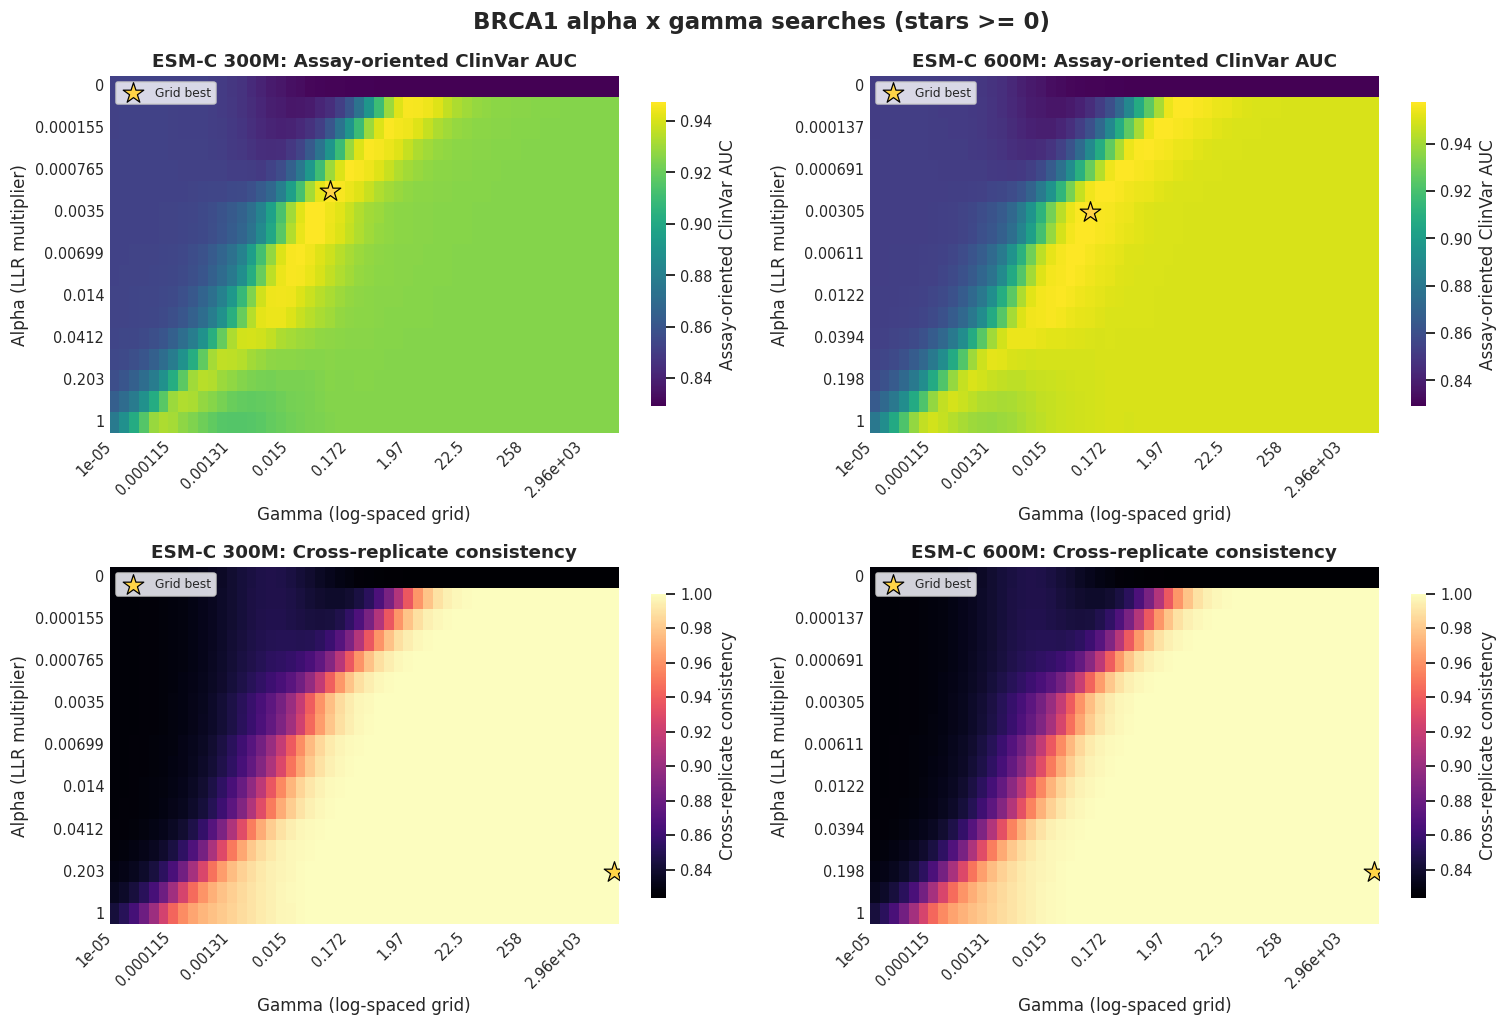

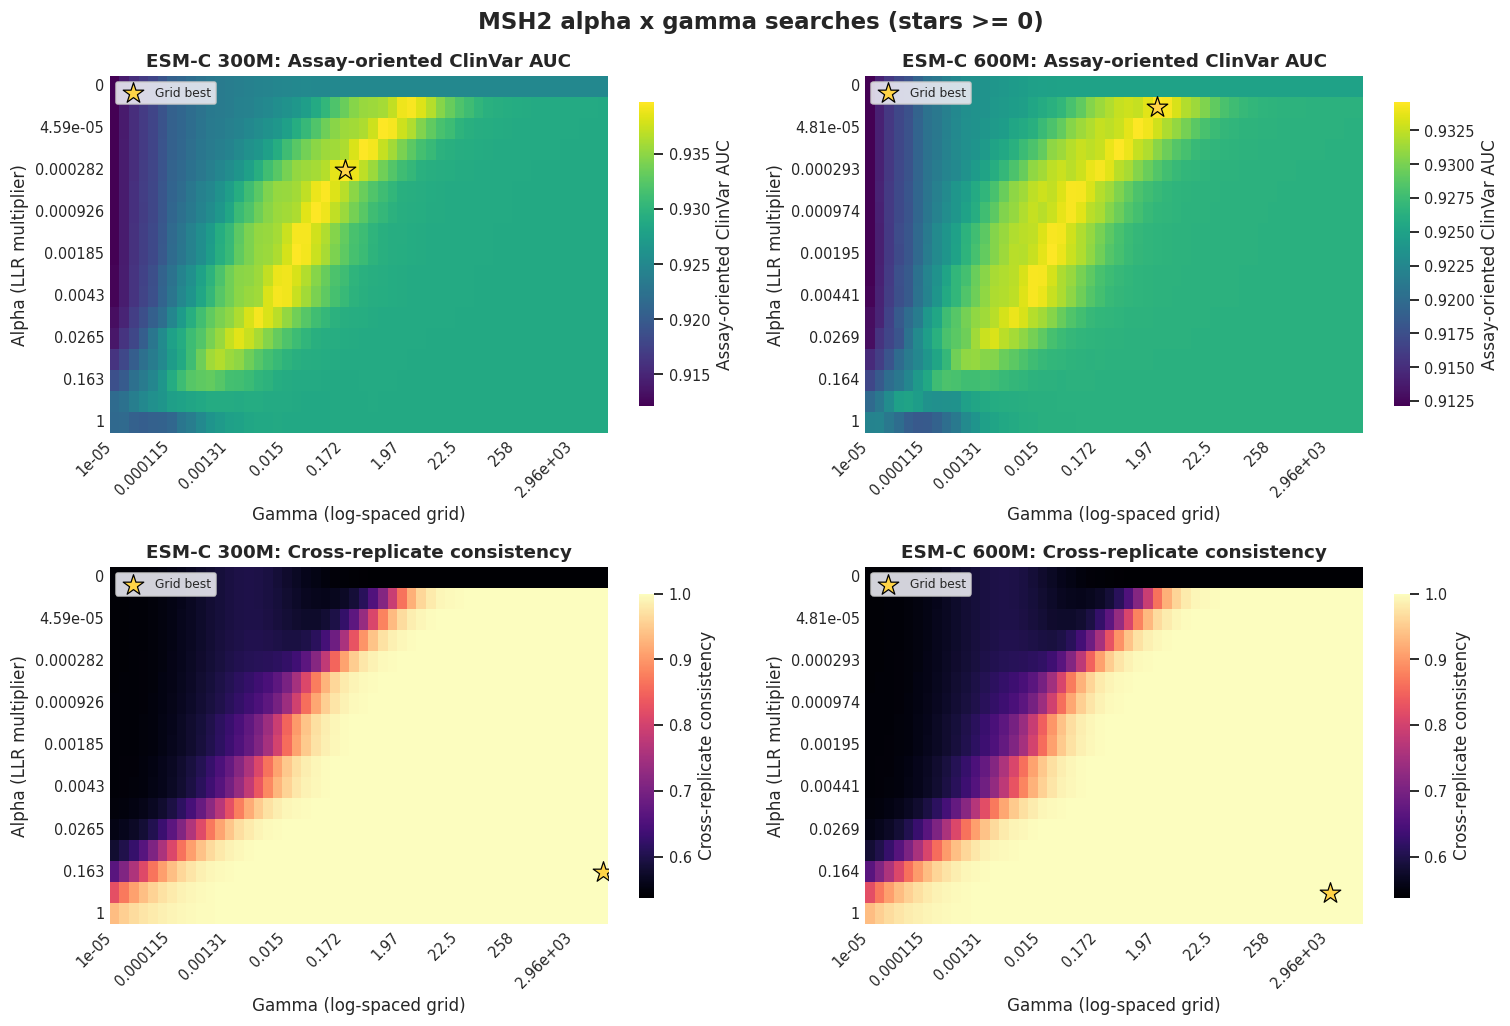

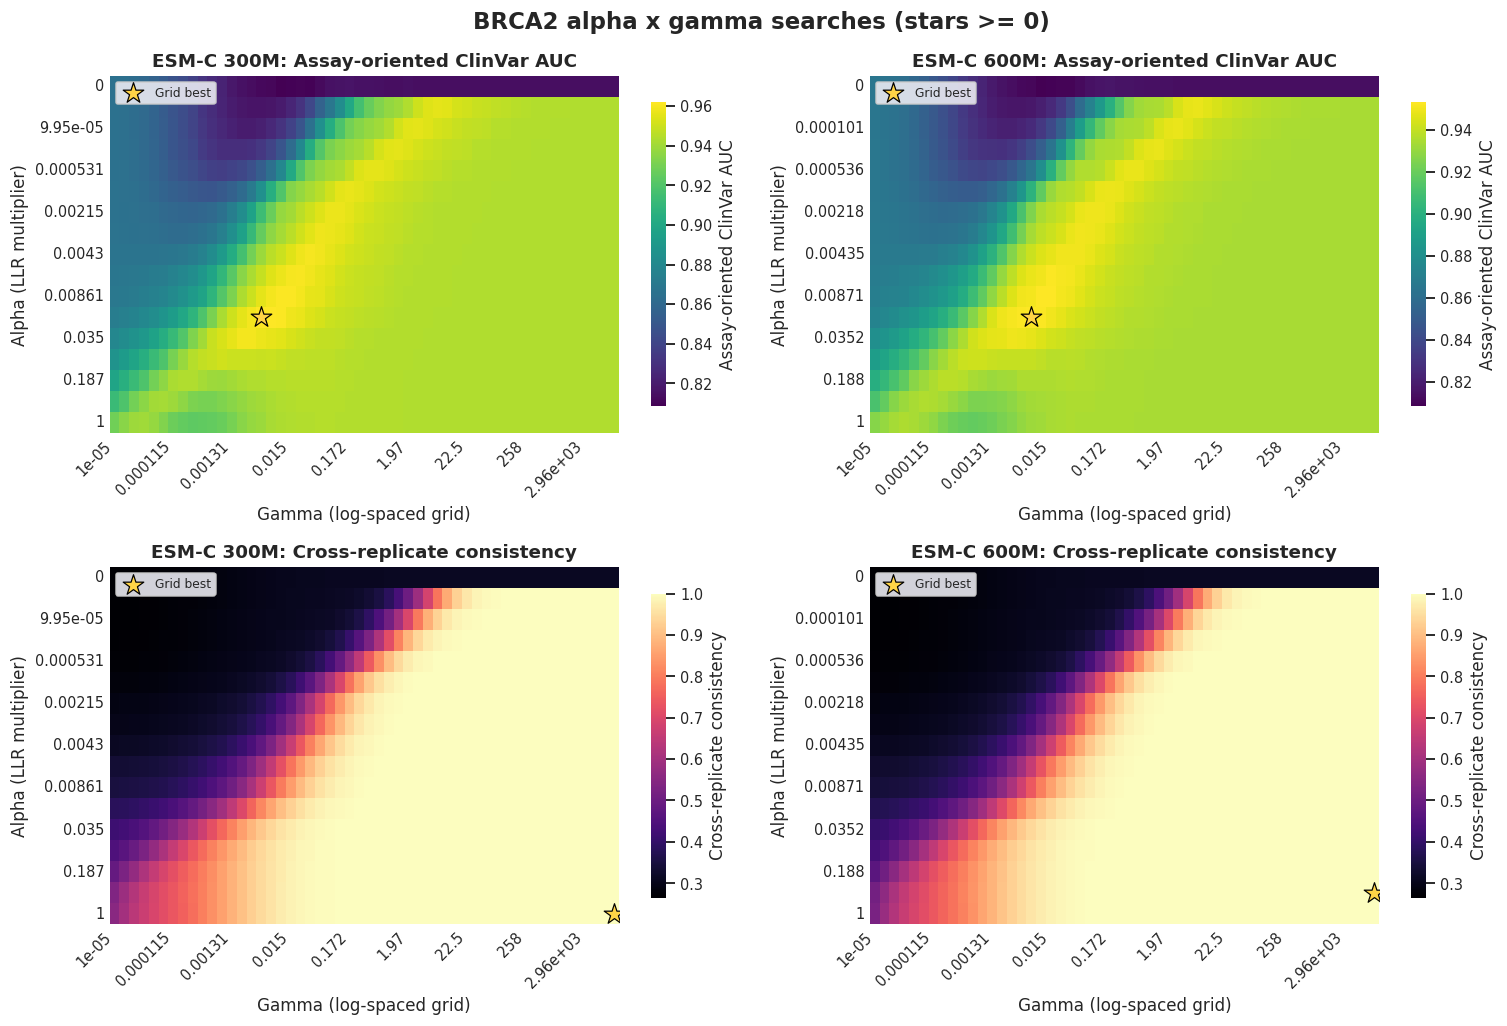

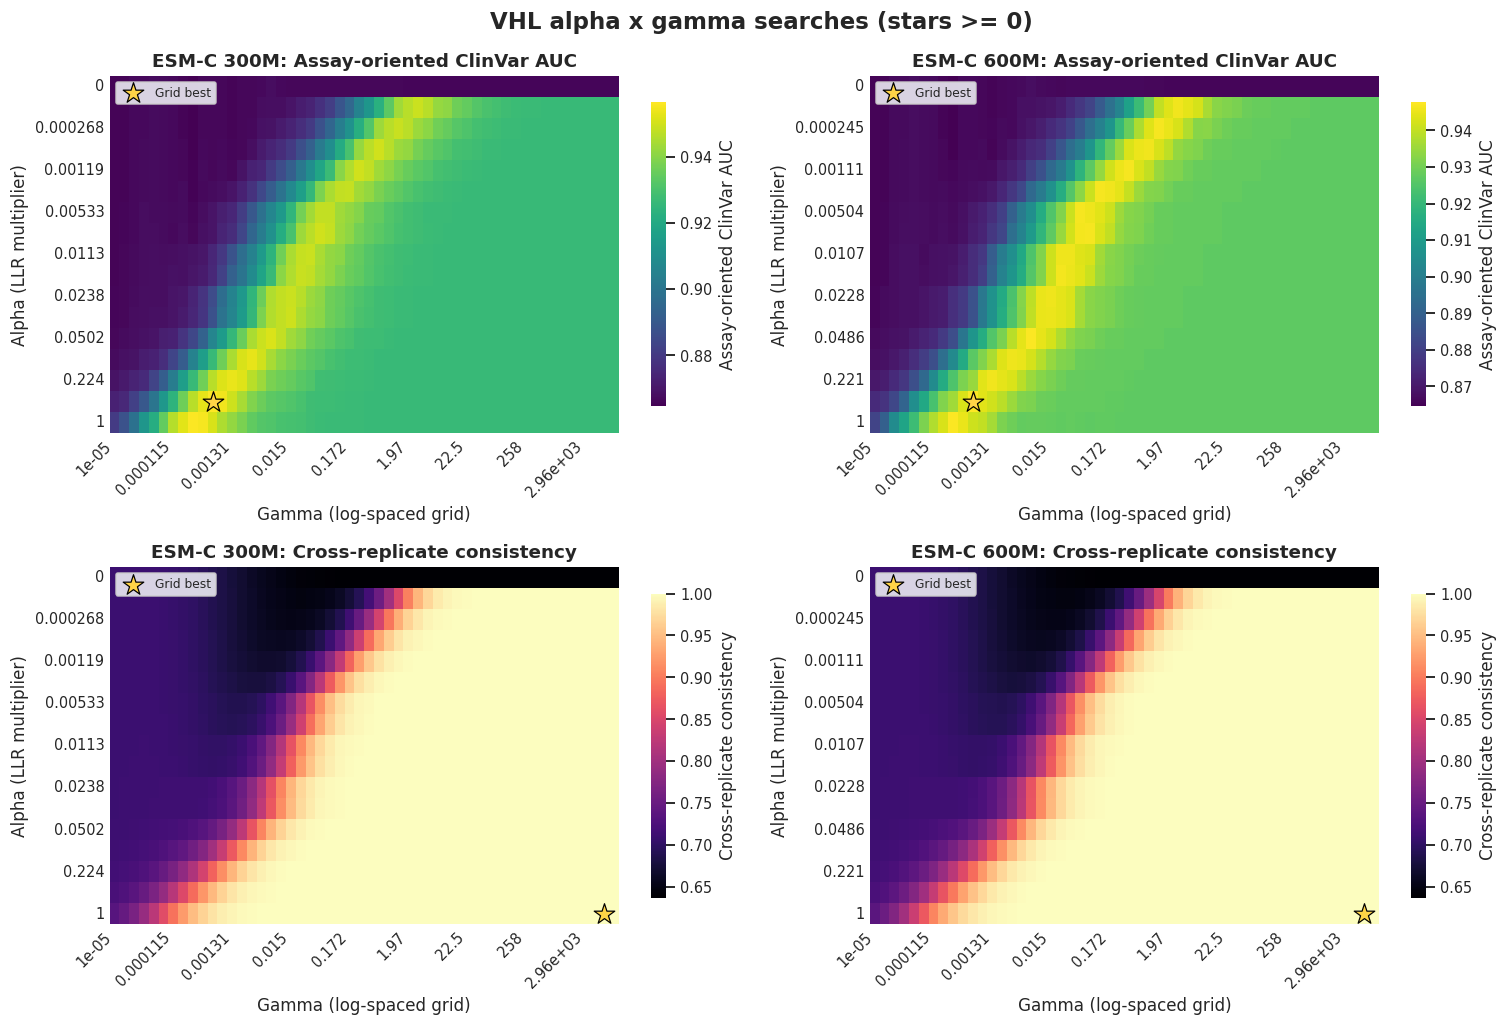

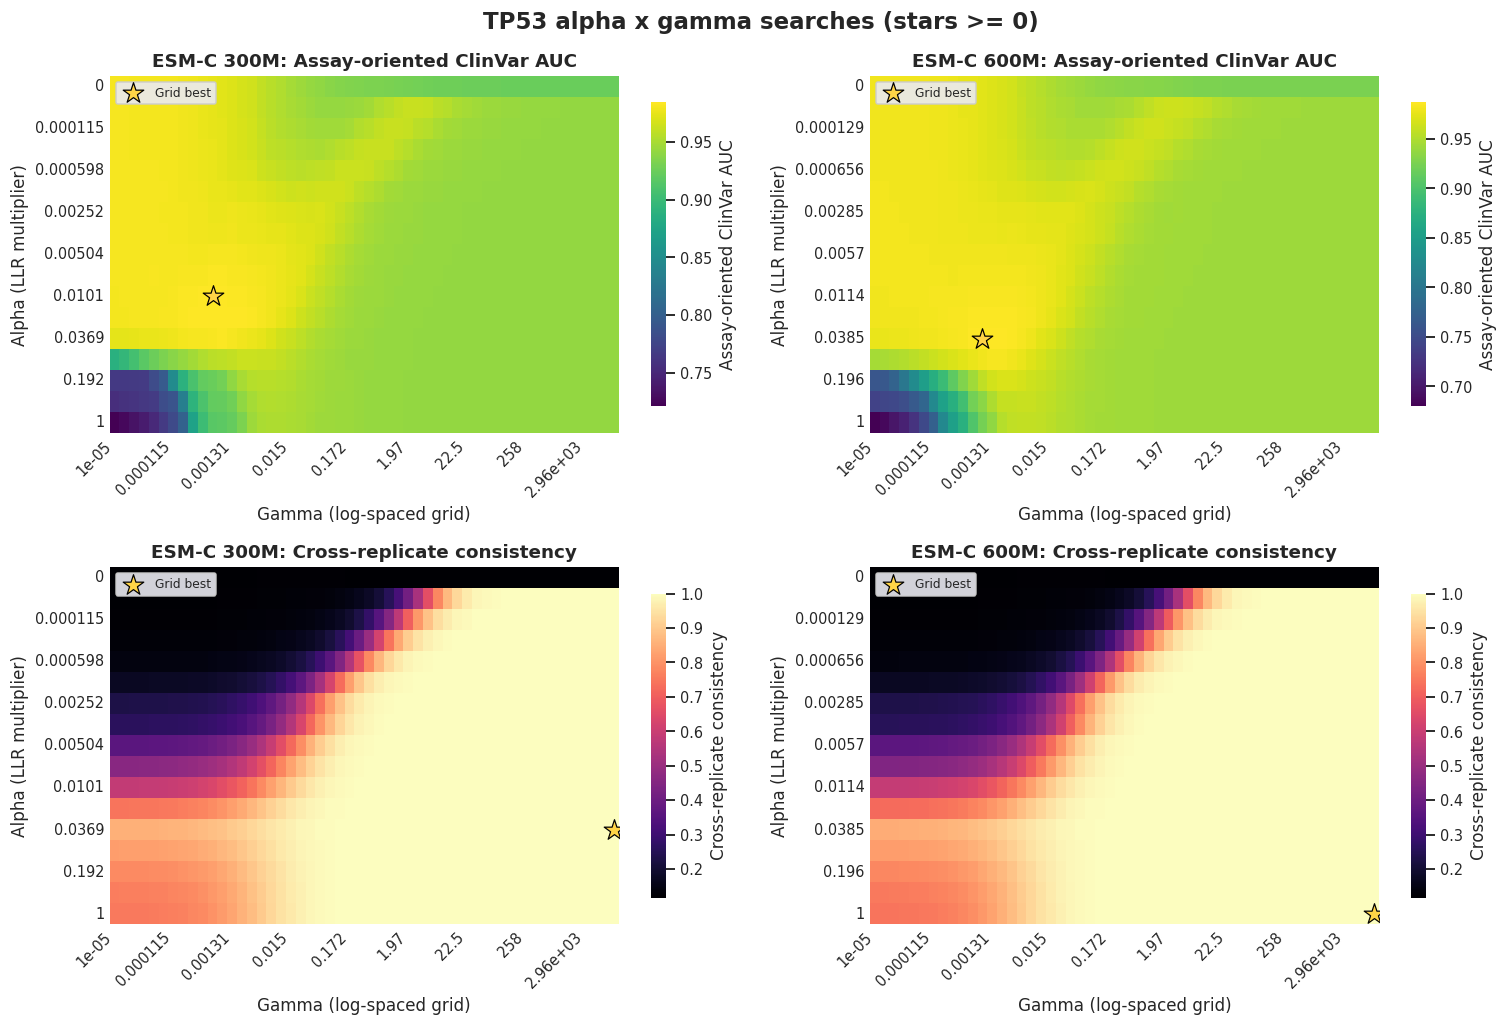

In [9]:
if not sweeps.empty:
    auc_column = f"auc_discrimination_stars_{PLOT_STAR_CUTOFF}"
    for dataset in DATASETS:
        dataset_sweep = sweeps[sweeps["dataset"].eq(dataset)]
        fig, axes = plt.subplots(2, 2, figsize=(14, 9.5), squeeze=False)
        for column, model_label in enumerate(MODELS):
            panel = dataset_sweep[dataset_sweep["prior_model"].eq(model_label)]
            for row, (metric, title, cmap) in enumerate([
                (auc_column, AUC_LABEL, "viridis"),
                ("cross_replicate_consistency", "Cross-replicate consistency", "magma"),
            ]):
                ax = axes[row, column]
                pivot = panel.pivot(index="alpha", columns="gamma", values=metric).sort_index().sort_index(axis=1)
                best = np.unravel_index(np.nanargmax(pivot.to_numpy()), pivot.shape)
                pivot.index = [f"{value:.3g}" for value in pivot.index]
                pivot.columns = [f"{value:.3g}" for value in pivot.columns]
                sns.heatmap(
                    pivot, ax=ax, cmap=cmap,
                    xticklabels=max(1, len(pivot.columns) // 8),
                    yticklabels=max(1, len(pivot.index) // 8),
                    cbar_kws={"label": title, "shrink": 0.85},
                )
                ax.scatter(best[1] + 0.5, best[0] + 0.5, label="Grid best", **BEST_MARKER)
                ax.set_title(f"{model_label}: {title}")
                ax.set_xlabel("Gamma (log-spaced grid)")
                ax.set_ylabel("Alpha (LLR multiplier)")
                plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
                plt.setp(ax.get_yticklabels(), rotation=0)
                ax.legend(loc="upper left", fontsize=8)
                tidy_heatmap(ax)
        finalize_figure(
            fig,
            f"{dataset}_300M_600M_alpha_gamma_surfaces_stars{PLOT_STAR_CUTOFF}.png",
            suptitle=f"{SHORT_NAMES[dataset]} alpha x gamma searches (stars >= {PLOT_STAR_CUTOFF})",
        )


## Five datasets at once, compared with their available baselines

Each panel compares pure LLR and the jointly optimized alpha/gamma result for each singular
model. Other recalculated baselines are shown as
horizontal references for that dataset and star cutoff. The second figure summarizes optimized
AUC and improvement over the best non-LLR-prior baseline across all five datasets.

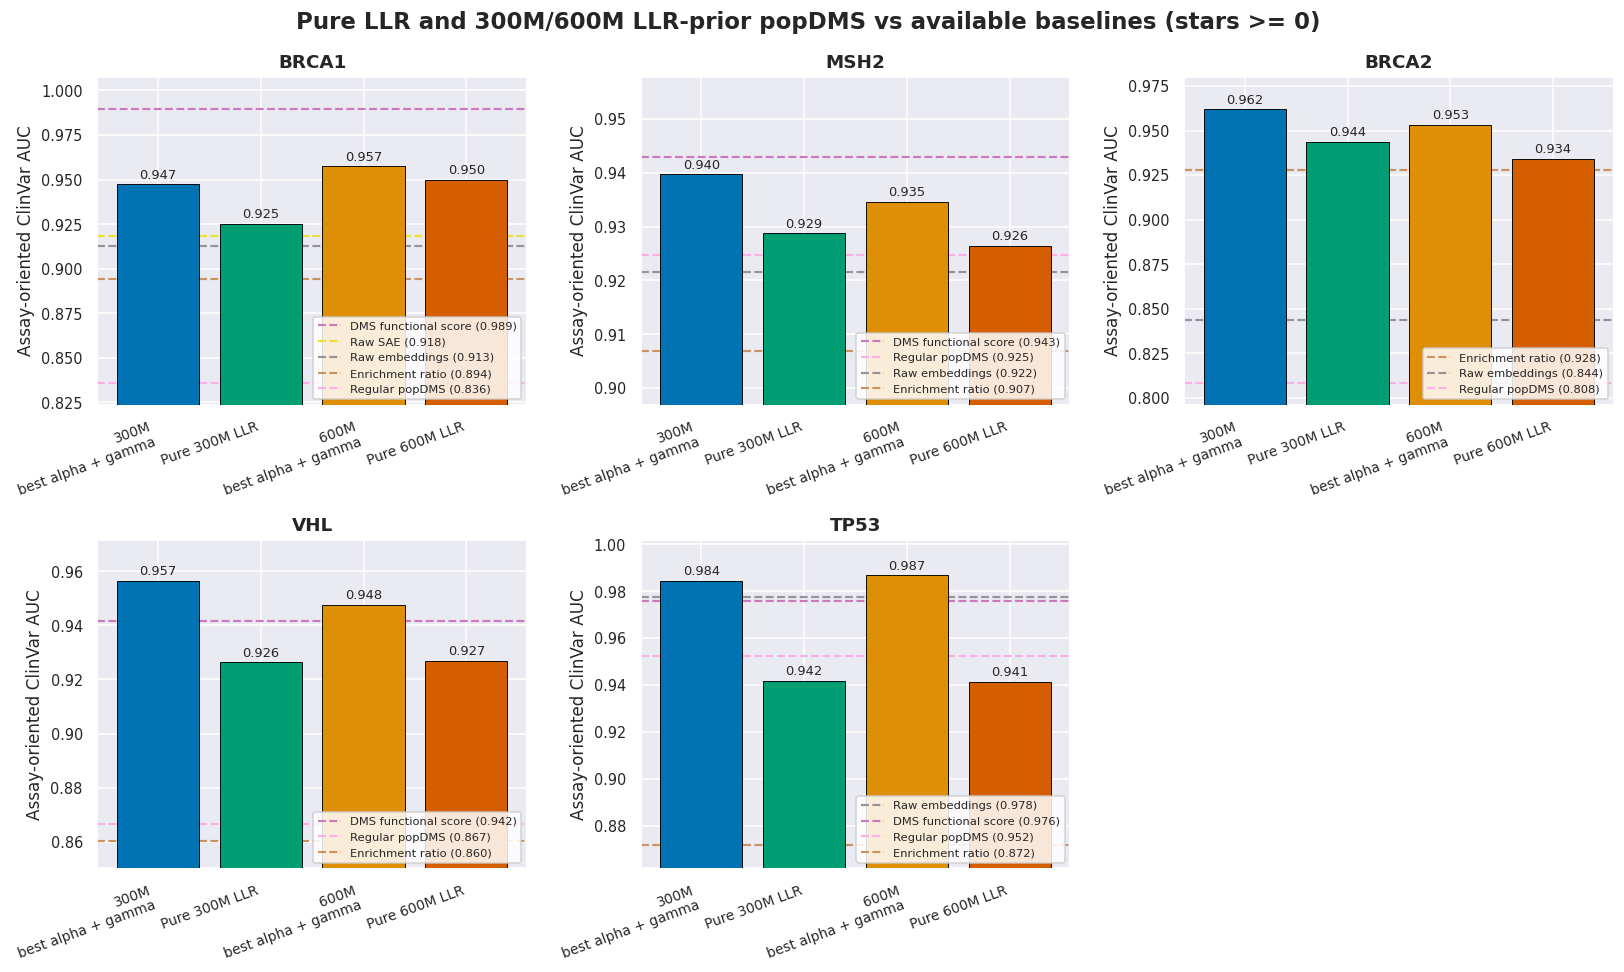

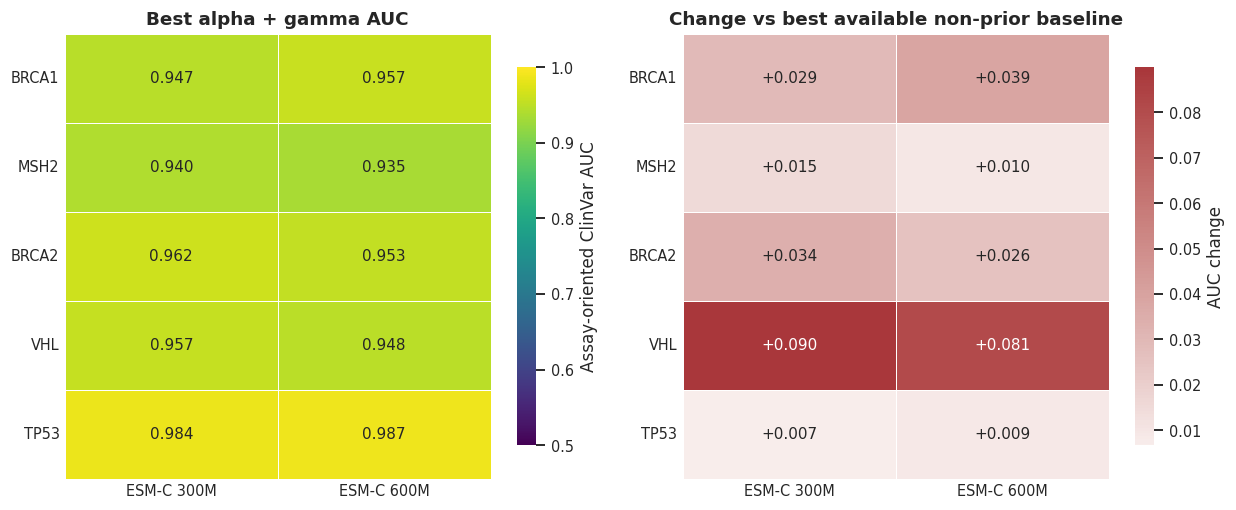

,dataset,prior_model,fit,auc_discrimination,alpha,gamma
0,MV_BRCA1_Findlay_2018,ESM-C 300M,best alpha + gamma,0.947263,0.001697,0.076270
1,MV_BRCA1_Findlay_2018,ESM-C 600M,best alpha + gamma,0.957419,0.003054,0.076270
2,MV_BRCA2_Huang_2025,ESM-C 300M,best alpha + gamma,0.961905,0.015164,0.004437
3,MV_BRCA2_Huang_2025,ESM-C 600M,best alpha + gamma,0.953247,0.015234,0.006661
4,MV_MSH2_Jia_2020,ESM-C 300M,best alpha + gamma,0.939684,0.000282,0.171907
5,MV_MSH2_Jia_2020,ESM-C 600M,best alpha + gamma,0.934569,0.000019,1.968419
6,MV_TP53_Kotler_2018,ESM-C 300M,best alpha + gamma,0.984393,0.010082,0.000582
7,MV_TP53_Kotler_2018,ESM-C 600M,best alpha + gamma,0.986671,0.038485,0.000873
8,MV_VHL_Buckley_2024,ESM-C 300M,best alpha + gamma,0.956522,0.473432,0.000582
9,MV_VHL_Buckley_2024,ESM-C 600M,best alpha + gamma,0.947649,0.469625,0.000582


In [14]:
if not sweeps.empty:
    auc_column = f"auc_discrimination_stars_{PLOT_STAR_CUTOFF}"
    summary_rows = []
    for (dataset, model), panel in sweeps.groupby(["dataset", "prior_model"]):
        tuned = panel.sort_values([auc_column, "alpha", "gamma"], ascending=[False, True, True]).iloc[0]
        summary_rows.append(
            {"dataset": dataset, "prior_model": model, "fit": "best alpha + gamma",
             "auc_discrimination": tuned[auc_column], "alpha": tuned["alpha"], "gamma": tuned["gamma"]}
        )
    sweep_summary = pd.DataFrame(summary_rows)
    sweep_summary.to_csv(TABLE_DIR / f"five_dataset_llr_prior_summary_stars{PLOT_STAR_CUTOFF}.csv", index=False)

    baseline_panel = baselines[baselines["min_review_stars"].eq(PLOT_STAR_CUTOFF)].copy()
    baseline_order, method_order = BASELINE_ORDER, METHOD_ORDER
    baseline_colors = method_colors = SERIES_COLORS
    prior_methods = sweep_summary.copy()
    prior_methods["method"] = prior_methods["prior_model"] + ": " + prior_methods["fit"]
    pure_llr_methods = baseline_panel[
        baseline_panel["baseline"].isin(["Raw ESM-C 300M LLR", "Raw ESM-C 600M LLR"])
    ].copy()
    pure_llr_methods["method"] = pure_llr_methods["baseline"].str.replace("Raw ", "Pure ", regex=False)
    comparison_methods = pd.concat([
        prior_methods[["dataset", "method", "auc_discrimination"]],
        pure_llr_methods[["dataset", "method", "auc_discrimination"]],
    ], ignore_index=True)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9), squeeze=False)
    for ax, dataset in zip(axes.ravel(), DATASETS):
        panel = comparison_methods[comparison_methods["dataset"].eq(dataset)].copy()
        panel["method"] = pd.Categorical(panel["method"], categories=method_order, ordered=True)
        panel = panel.sort_values("method")
        panel["label"] = (panel["method"].astype(str)
                          .str.replace("ESM-C ", "", regex=False)
                          .str.replace(": ", "\n", regex=False))
        bars = ax.bar(np.arange(len(panel)), panel["auc_discrimination"],
                      color=[SERIES_COLORS[str(method)] for method in panel["method"]],
                      edgecolor="black", linewidth=0.6, zorder=3)
        references = baseline_panel[
            baseline_panel["dataset"].eq(dataset)
            & ~baseline_panel["baseline"].isin(["Raw ESM-C 300M LLR", "Raw ESM-C 600M LLR"])
        ]
        for _, row in references.iterrows():
            if np.isfinite(row["auc_discrimination"]):
                ax.axhline(row["auc_discrimination"], color=SERIES_COLORS.get(row["baseline"], "0.4"),
                           linestyle="--", linewidth=1.4, zorder=2,
                           label=f"{row['baseline']} ({row['auc_discrimination']:.3f})")
        ax.bar_label(bars, fmt="%.3f", fontsize=8.5, padding=2)
        ax.set_xticks(np.arange(len(panel)), panel["label"], rotation=20, ha="right", fontsize=9)
        ax.set_title(SHORT_NAMES[dataset])
        ax.set_ylabel(AUC_LABEL)
        ax.set_axisbelow(True)
        displayed_auc = np.r_[
            panel["auc_discrimination"].to_numpy(float),
            references["auc_discrimination"].to_numpy(float),
        ]
        displayed_auc = displayed_auc[np.isfinite(displayed_auc)]
        if displayed_auc.size:
            worst, best = float(displayed_auc.min()), float(displayed_auc.max())
            padding = max(0.01, 0.08 * max(best - worst, 0.01))
            ax.set_ylim(max(0.0, worst - padding), min(1.01, best + 1.5 * padding))
        ax.legend(fontsize=7.5, loc="lower right", facecolor="white", framealpha=0.85)
    axes.ravel()[-1].axis("off")
    finalize_figure(
        fig,
        f"five_dataset_llr_prior_vs_baselines_stars{PLOT_STAR_CUTOFF}.png",
        suptitle=("Pure LLR and 300M/600M LLR-prior popDMS vs available baselines "
                  f"(stars >= {PLOT_STAR_CUTOFF})"),
    )

    nonprior_mask = (
        ~baseline_panel["baseline"].str.startswith("Raw ESM-C")
        & baseline_panel["baseline"].ne("DMS functional score")
    )
    best_nonprior = (baseline_panel[nonprior_mask]
                     .groupby("dataset")["auc_discrimination"].max())
    tuned = sweep_summary[sweep_summary["fit"].eq("best alpha + gamma")].copy()
    tuned["improvement_over_best_baseline"] = tuned.apply(
        lambda row: row["auc_discrimination"] - best_nonprior.get(row["dataset"], np.nan), axis=1
    )
    heat_auc = tuned.pivot(index="dataset", columns="prior_model", values="auc_discrimination").loc[DATASETS]
    heat_delta = tuned.pivot(index="dataset", columns="prior_model", values="improvement_over_best_baseline").loc[DATASETS]
    heat_auc.index = [SHORT_NAMES[item] for item in heat_auc.index]
    heat_delta.index = heat_auc.index
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), squeeze=False)
    axes = axes.ravel()
    sns.heatmap(heat_auc, annot=True, fmt=".3f", cmap="viridis", vmin=0.5, vmax=1.0,
                linewidths=0.5, linecolor="white", annot_kws={"fontsize": 10}, ax=axes[0],
                cbar_kws={"label": AUC_LABEL, "shrink": 0.85})
    sns.heatmap(heat_delta, annot=True, fmt="+.3f", cmap="vlag", center=0,
                linewidths=0.5, linecolor="white", annot_kws={"fontsize": 10}, ax=axes[1],
                cbar_kws={"label": "AUC change", "shrink": 0.85})
    axes[0].set_title("Best alpha + gamma AUC")
    axes[1].set_title("Change vs best available non-prior baseline")
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="y", rotation=0)
        tidy_heatmap(ax)
    finalize_figure(fig, f"five_dataset_llr_prior_auc_heatmaps_stars{PLOT_STAR_CUTOFF}.png")
    display(sweep_summary)


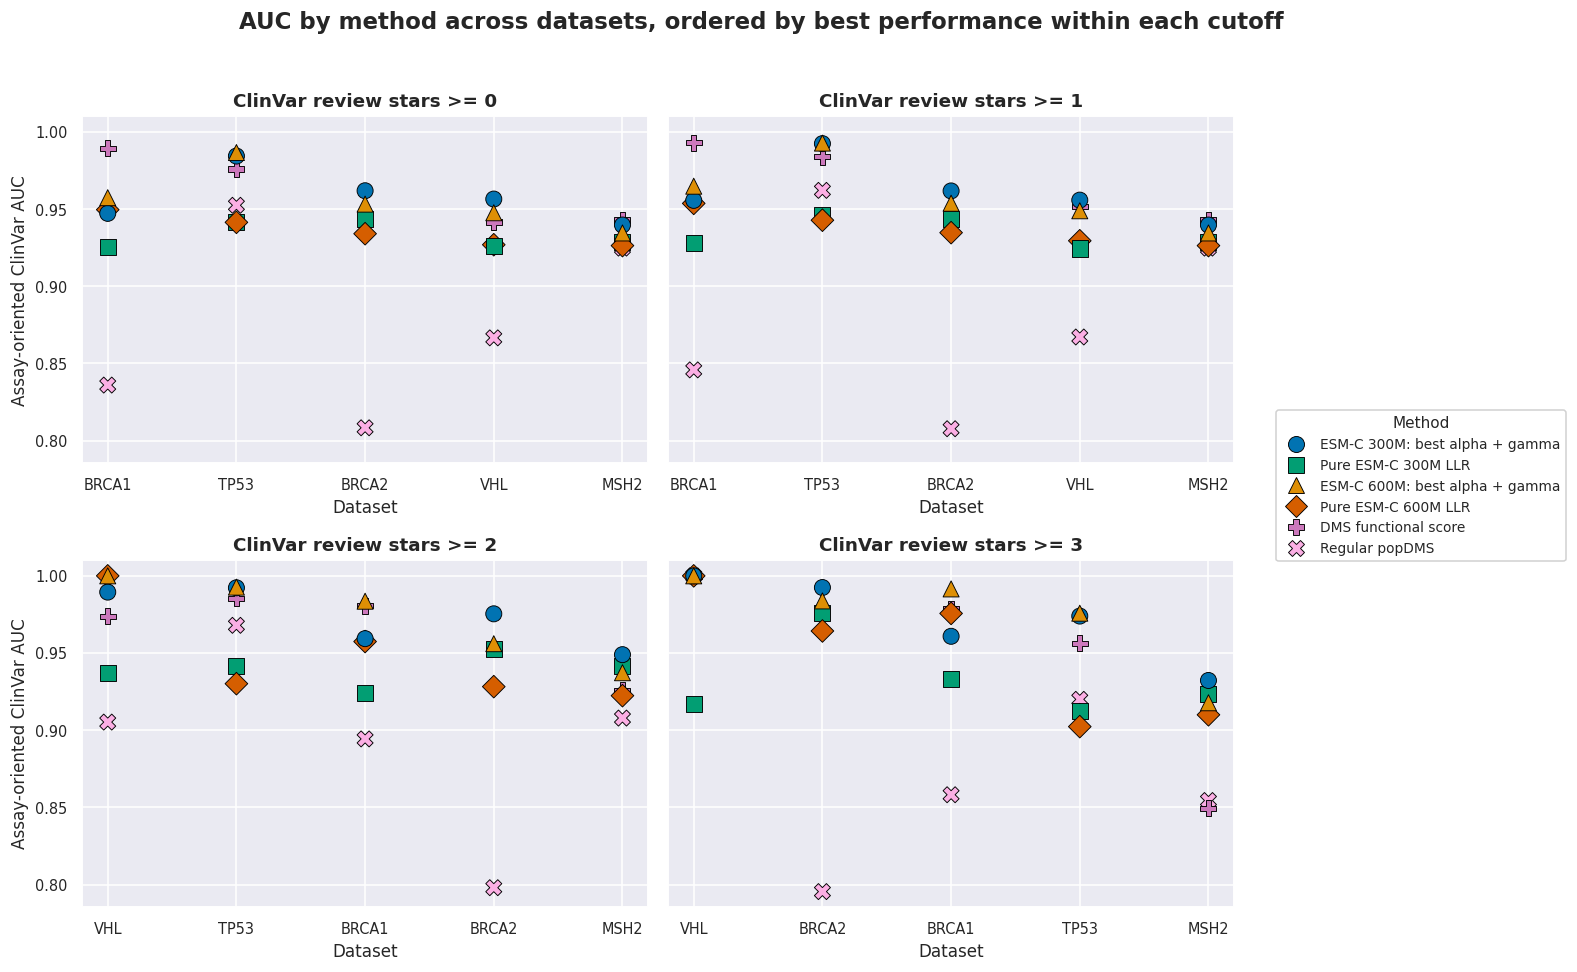

In [15]:
if not sweeps.empty:
    dot_baseline_names = ["DMS functional score", "Regular popDMS"]
    dot_method_order = METHOD_ORDER + dot_baseline_names
    dot_markers = dict(zip(dot_method_order, ["o", "s", "^", "D", "P", "X"]))
    # Drawn back to front, so the tuned ESM-C LLR priors stay visible where points coincide.
    DOT_LAYERS = [
        dot_baseline_names,
        ["Pure ESM-C 300M LLR", "Pure ESM-C 600M LLR"],
        ["ESM-C 300M: best alpha + gamma", "ESM-C 600M: best alpha + gamma"],
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True, squeeze=False)
    for ax, cutoff in zip(axes.ravel(), REVIEW_STAR_CUTOFFS):
        cutoff_auc_column = f"auc_discrimination_stars_{cutoff}"
        cutoff_prior_rows = []
        for (dataset, model), panel in sweeps.groupby(["dataset", "prior_model"]):
            tuned = panel.sort_values(
                [cutoff_auc_column, "alpha", "gamma"], ascending=[False, True, True]
            ).iloc[0]
            cutoff_prior_rows.append({
                "dataset": dataset,
                "method": f"{model}: best alpha + gamma",
                "auc_discrimination": tuned[cutoff_auc_column],
            })
        cutoff_baselines = baselines[baselines["min_review_stars"].eq(cutoff)].copy()
        pure_llr = cutoff_baselines[
            cutoff_baselines["baseline"].isin(["Raw ESM-C 300M LLR", "Raw ESM-C 600M LLR"])
        ].copy()
        pure_llr["method"] = pure_llr["baseline"].str.replace("Raw ", "Pure ", regex=False)
        dot_baselines = cutoff_baselines[
            cutoff_baselines["baseline"].isin(dot_baseline_names)
        ].copy()
        dot_baselines["method"] = dot_baselines["baseline"]
        dot_data = pd.concat([
            pd.DataFrame(cutoff_prior_rows),
            pure_llr[["dataset", "method", "auc_discrimination"]],
            dot_baselines[["dataset", "method", "auc_discrimination"]],
        ], ignore_index=True)
        best_auc_by_dataset = (dot_data.groupby("dataset", sort=False)["auc_discrimination"]
                               .max().sort_values(ascending=False, kind="stable"))
        dataset_order = [SHORT_NAMES[dataset] for dataset in best_auc_by_dataset.index]
        dot_data["dataset_label"] = pd.Categorical(
            dot_data["dataset"].map(SHORT_NAMES), categories=dataset_order, ordered=True
        )
        dot_data["method"] = pd.Categorical(
            dot_data["method"], categories=dot_method_order, ordered=True
        )
        for depth, layer_methods in enumerate(DOT_LAYERS):
            layer = dot_data[dot_data["method"].isin(layer_methods)].copy()
            layer["method"] = layer["method"].astype(str)
            sns.scatterplot(
                data=layer, x="dataset_label", y="auc_discrimination",
                hue="method", style="method",
                hue_order=layer_methods, style_order=layer_methods,
                palette={name: SERIES_COLORS[name] for name in layer_methods},
                markers={name: dot_markers[name] for name in layer_methods},
                s=110, edgecolor="black", linewidth=0.6, zorder=3 + depth, ax=ax,
            )
        ax.set_xlabel("Dataset")
        ax.set_ylabel(AUC_LABEL)
        ax.set_title(f"ClinVar review stars >= {cutoff}")
        ax.tick_params(axis="x", rotation=0)
        ax.set_axisbelow(True)
    # Layering changes the draw order, so restore the intended legend order by label.
    layer_handles, layer_labels = axes[0, 0].get_legend_handles_labels()
    handle_by_label = dict(zip(layer_labels, layer_handles))
    labels = [name for name in dot_method_order if name in handle_by_label]
    handles = [handle_by_label[name] for name in labels]
    for ax in axes.ravel():
        if ax.legend_ is not None:
            ax.legend_.remove()
    fig.legend(handles, labels, title="Method", loc="center left",
               bbox_to_anchor=(0.83, 0.5), facecolor="white", framealpha=0.9)
    finalize_figure(
        fig, "five_dataset_llr_methods_dotplot_all_star_cutoffs.png",
        suptitle="AUC by method across datasets, ordered by best performance within each cutoff",
        rect=(0, 0, 0.82, 0.96),
    )


## Best LLR-prior AUC across gamma

For each dataset, the model and alpha from the globally best AUC row are held fixed while
gamma varies. The star marks the selected best gamma.

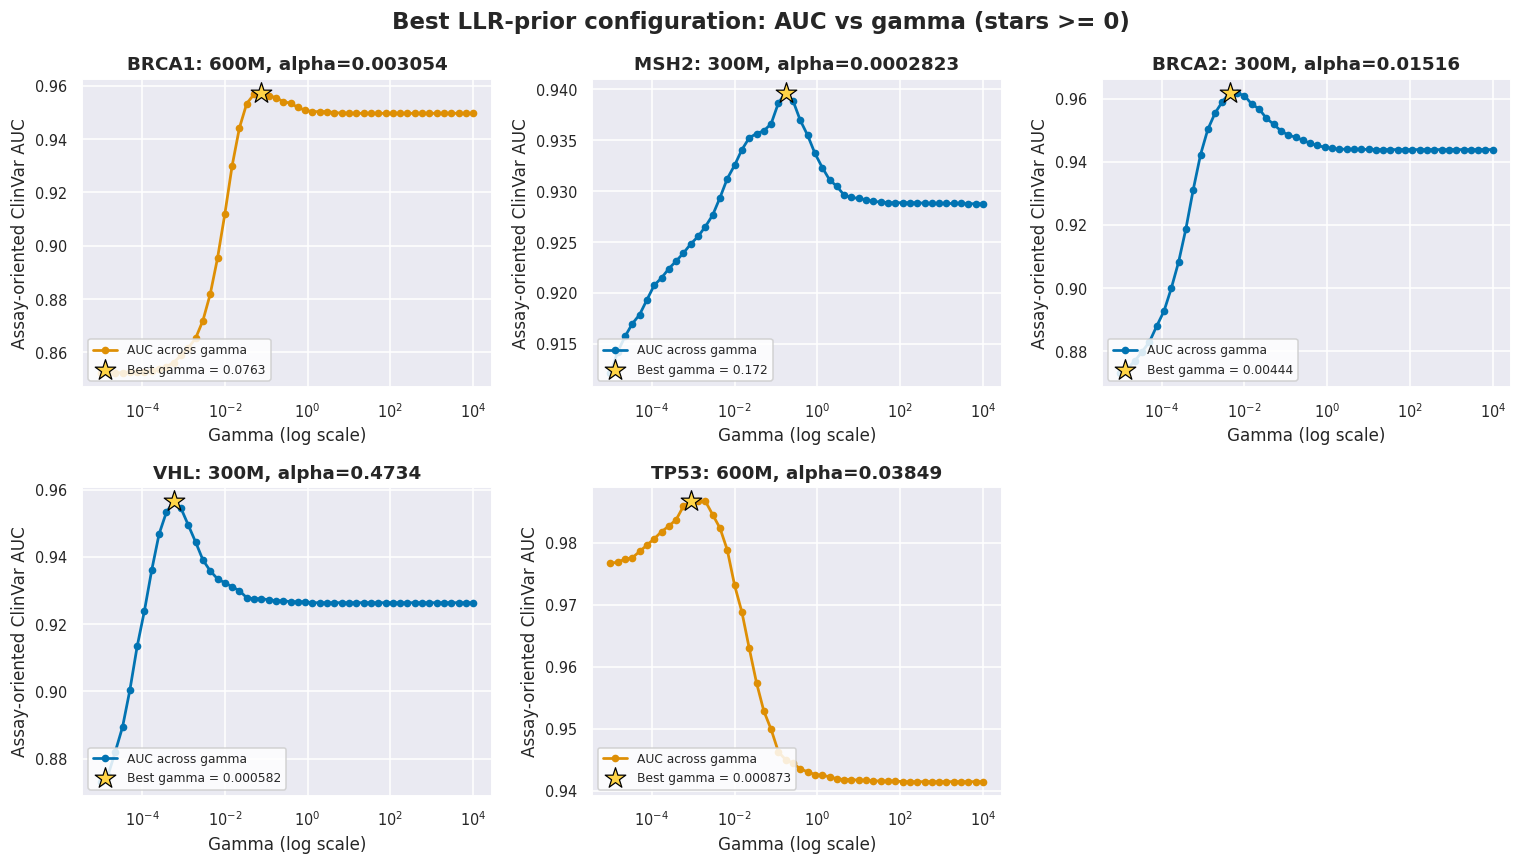

,dataset,prior_model,alpha,best_gamma,best_auc
0,MV_BRCA1_Findlay_2018,ESM-C 600M,0.003054,0.076270,0.957419
1,MV_MSH2_Jia_2020,ESM-C 300M,0.000282,0.171907,0.939684
2,MV_BRCA2_Huang_2025,ESM-C 300M,0.015164,0.004437,0.961905
3,MV_VHL_Buckley_2024,ESM-C 300M,0.473432,0.000582,0.956522
4,MV_TP53_Kotler_2018,ESM-C 600M,0.038485,0.000873,0.986671


In [16]:
if not sweeps.empty:
    auc_column = f"auc_discrimination_stars_{PLOT_STAR_CUTOFF}"
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), squeeze=False, sharey=False)
    best_gamma_rows = []
    for ax, dataset in zip(axes.ravel(), DATASETS):
        dataset_sweep = sweeps[sweeps["dataset"].eq(dataset)].copy()
        best_row = dataset_sweep.sort_values(
            [auc_column, "prior_model", "alpha", "gamma"],
            ascending=[False, True, True, True],
        ).iloc[0]
        trace = dataset_sweep[
            dataset_sweep["prior_model"].eq(best_row["prior_model"])
            & np.isclose(dataset_sweep["alpha"], best_row["alpha"])
        ].sort_values("gamma")
        ax.plot(trace["gamma"], trace[auc_column], marker="o", markersize=4,
                color=SERIES_COLORS[f"{best_row['prior_model']}: best alpha + gamma"],
                label="AUC across gamma", zorder=3)
        ax.scatter(best_row["gamma"], best_row[auc_column],
                   label=f"Best gamma = {best_row['gamma']:.3g}", **BEST_MARKER)
        ax.set_xscale("log")
        ax.set_xlabel("Gamma (log scale)")
        ax.set_ylabel(AUC_LABEL)
        ax.set_title(
            f"{SHORT_NAMES[dataset]}: {best_row['prior_model'].replace('ESM-C ', '')}, "
            f"alpha={best_row['alpha']:.4g}"
        )
        ax.set_axisbelow(True)
        ax.legend(loc="lower left", fontsize=8, facecolor="white", framealpha=0.85)
        best_gamma_rows.append({
            "dataset": dataset,
            "prior_model": best_row["prior_model"],
            "alpha": float(best_row["alpha"]),
            "best_gamma": float(best_row["gamma"]),
            "best_auc": float(best_row[auc_column]),
        })
    axes.ravel()[-1].axis("off")
    finalize_figure(
        fig, f"five_dataset_best_llr_prior_auc_vs_gamma_stars{PLOT_STAR_CUTOFF}.png",
        suptitle=f"Best LLR-prior configuration: AUC vs gamma (stars >= {PLOT_STAR_CUTOFF})",
    )
    display(pd.DataFrame(best_gamma_rows))


## BRCA1-only SAE benchmark view

This section consumes the already-calculated BRCA1 SAE models and raw embedding benchmarks.
It does not load SAE outputs for the other four datasets. Their optional jobs above remain
independent of all LLR-prior tables and plots.

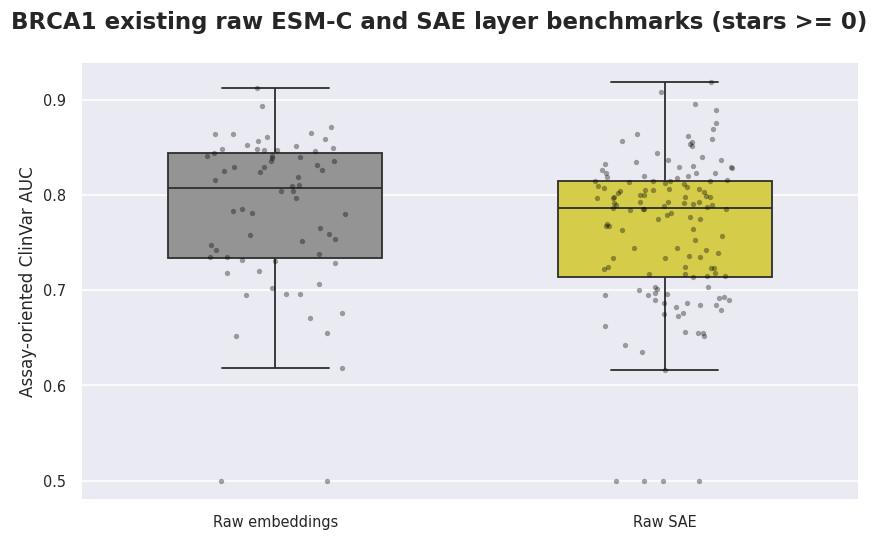

In [17]:
brca1_existing = existing_embedding_benchmarks("MV_BRCA1_Findlay_2018")
brca1_existing = brca1_existing[brca1_existing["min_review_stars"].eq(PLOT_STAR_CUTOFF)]
if brca1_existing.empty:
    print("No collected BRCA1 raw-embedding/SAE benchmark fitness files were found.")
else:
    box_order = ["Raw embeddings", "Raw SAE"]
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=brca1_existing, x="baseline", y="auc_discrimination", ax=ax,
                order=box_order, palette=SERIES_COLORS, hue="baseline", hue_order=box_order,
                legend=False, width=0.55, linewidth=1.2, fliersize=0)
    sns.stripplot(data=brca1_existing, x="baseline", y="auc_discrimination", ax=ax,
                  order=box_order, color="black", alpha=0.35, size=3.5, jitter=0.18)
    ax.set_xlabel("")
    ax.set_ylabel(AUC_LABEL)
    ax.set_axisbelow(True)
    finalize_figure(
        fig, f"BRCA1_existing_raw_vs_sae_stars{PLOT_STAR_CUTOFF}.png",
        suptitle=f"BRCA1 existing raw ESM-C and SAE layer benchmarks (stars >= {PLOT_STAR_CUTOFF})",
    )


## Output checklist

- Joined data: `new_clean_data/joined_embeddings/*_joined.csv`
- LLR files: per-dataset `tables/*_300M_llr_fitness.csv` and `*_600M_llr_fitness.csv`
- Cached searches: `data/clinprotgym_esmc_sae/multi_dataset_llr_prior/tables/`
- Five-dataset plots: `data/clinprotgym_esmc_sae/multi_dataset_llr_prior/figures/`
- Primary downstream inputs: joined count/frequency data, 300M/600M LLRs, and respective baselines
- SAE downstream input: BRCA1 only